In [122]:
#import libraries(numpy,pandas,matplotlib,seaborn)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [123]:
#load dataset
data=pd.read_csv('C:/Users/chiru/OneDrive/Desktop/train.csv')
data.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [124]:
data.shape

(9800, 18)

In [125]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [126]:
#convert date datatype from object to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True)
data['Ship Date']  = pd.to_datetime(data['Ship Date'], dayfirst=True)
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
maping={1:'jan',2:'feb',3:'march',4:'april',5:'may',6:'june',7:'july',8:'aug',9:'sep',10:'oct',11:'nov',12:'dec'}
data['Month Name']=data['Month'].map(maping)

In [127]:
#check for null values
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
dtype: int64

In [128]:
#handling missing data
data['Postal Code'].fillna(0, inplace=True)
data['Postal Code'] = data['Postal Code'].astype(int)

In [129]:
#calculate shipping days
data['Shipping Days'] = (data['Ship Date'] - data['Order Date']).dt.days
data['Shipping Days'].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [130]:
#check for invalid shipping days
data[data['Shipping Days'] < 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Shipping Days


In [131]:
#sorting unique years
years = sorted(data['Year'].unique())

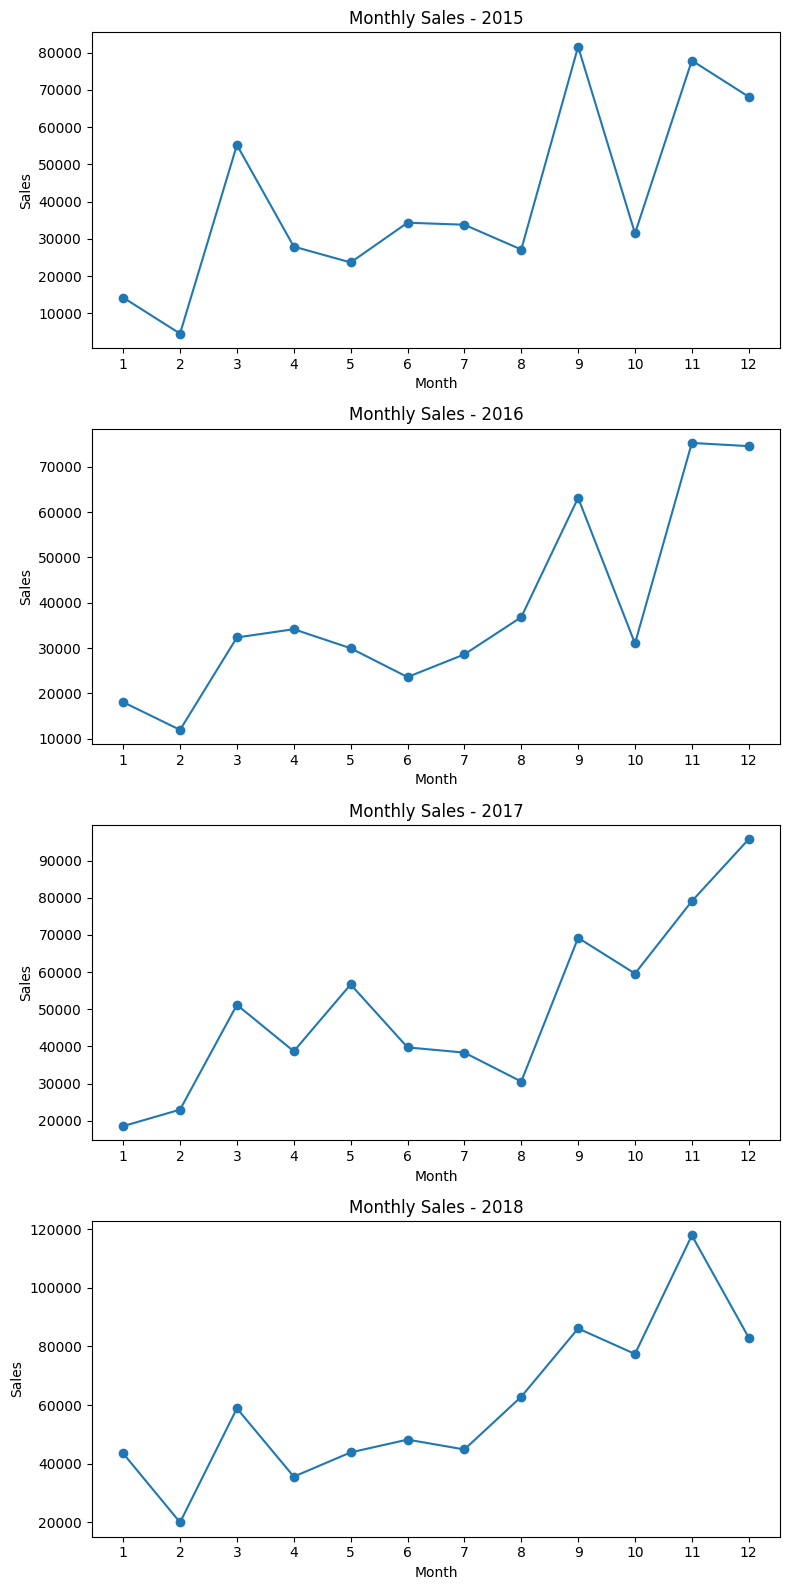

In [132]:
#monthly sales based on years
fig, axes = plt.subplots(len(years), 1, figsize=(8, 4 * len(years)))
for i, y in enumerate(years):
    year_data = data[data['Year'] == y]
    monthly_sales = year_data.groupby('Month')['Sales'].sum()

    axes[i].plot(monthly_sales,marker='o')
    axes[i].set_title(f'Monthly Sales - {y}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Sales')
    axes[i].set_xticks(range(1,13))
plt.tight_layout()
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/monthly sales.png')
plt.show()


In [133]:
#yearly sales
yearly_sales = data.groupby('Year')['Sales'].sum()
yearly_sales

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

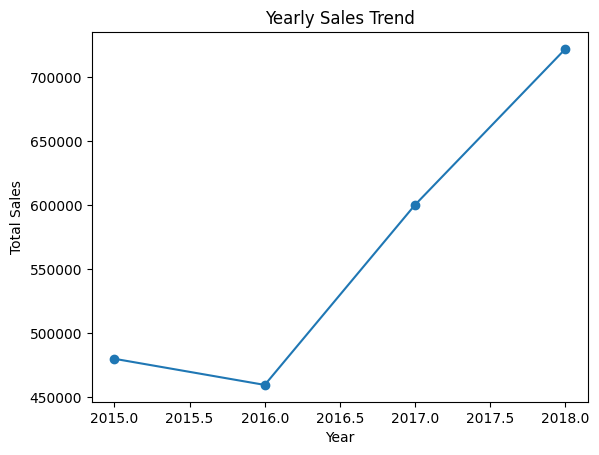

In [134]:

yearly_sales.plot(marker='o')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/yearly sales.png')
plt.show()

In [135]:
#yearly sales by categories
year_cat_sales = (
    data.groupby(['Year', 'Category'])['Sales']
    .sum()
    .reset_index()

)
year_cat_sales

,Year,Category,Sales
0,2015,Furniture,156477.8811
1,2015,Office Supplies,149512.8200
2,2015,Technology,173865.5070
3,2016,Furniture,164053.8674
4,2016,Office Supplies,133124.4070
5,2016,Technology,162257.7310
6,2017,Furniture,195813.0400
7,2017,Office Supplies,182417.5660
8,2017,Technology,221961.9440
9,2018,Furniture,212313.7872


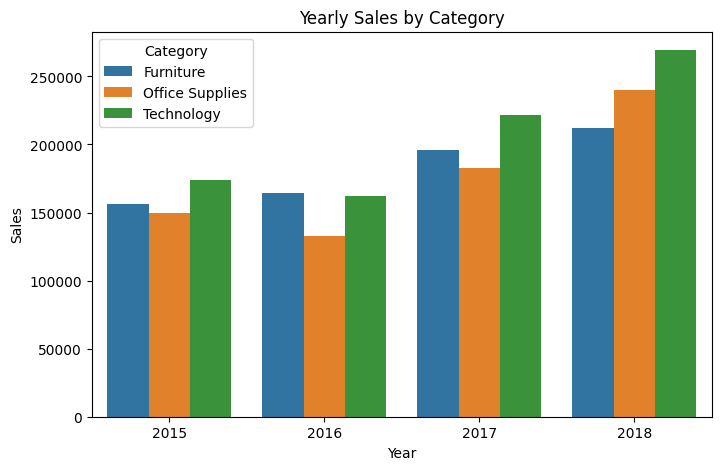

In [136]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=year_cat_sales,
    x='Year',
    y='Sales',
    hue='Category'
)
plt.title('Yearly Sales by Category')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/year-cat sales.png')
plt.show()

In [137]:
#yearly sales per segment
seg_year_sales = (
    data.groupby(['Year', 'Segment'])['Sales']
    .sum()
    .reset_index()
)
seg_year_sales

,Year,Segment,Sales
0,2015,Consumer,262956.8006
1,2015,Corporate,127797.4957
2,2015,Home Office,89101.9118
3,2016,Consumer,265356.2933
4,2016,Corporate,119675.5989
5,2016,Home Office,74404.1132
6,2017,Consumer,291142.9652
7,2017,Corporate,204977.3178
8,2017,Home Office,104072.2670
9,2018,Consumer,328604.4719


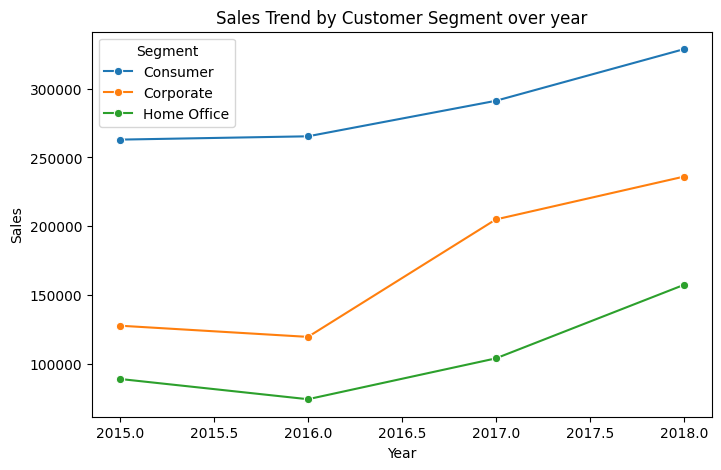

In [138]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=seg_year_sales,
    x='Year',
    y='Sales',
    hue='Segment',
    marker='o'
)
plt.title('Sales Trend by Customer Segment over year')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/year-seg sales.png')
plt.show()

In [139]:
#year over year sales growth
yoy_growth = yearly_sales.pct_change() * 100
yoy_growth

Year
2015          NaN
2016    -4.255484
2017    30.636812
2018    20.303396
Name: Sales, dtype: float64

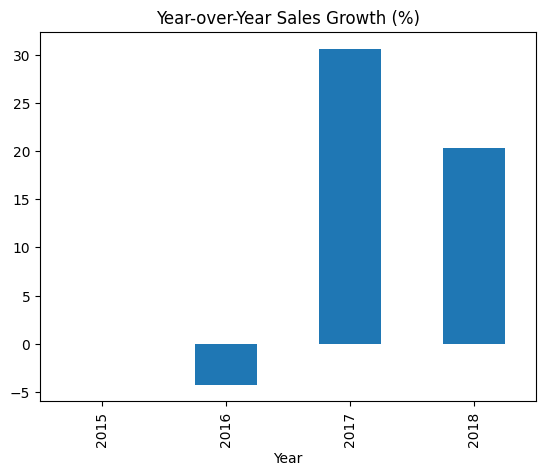

In [140]:
yoy_growth.plot(kind='bar', title='Year-over-Year Sales Growth (%)')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/yoy sales.png')
plt.show()

In [141]:
#year over year sales growth by categories
year_cat_sales = (
    data.groupby(['Year', 'Category'])['Sales']
    .sum()
    .unstack()
)
year_cat_sales

Category,Furniture,Office Supplies,Technology
Year,,,
2015,156477.8811,149512.820,173865.507
2016,164053.8674,133124.407,162257.731
2017,195813.0400,182417.566,221961.944
2018,212313.7872,240367.541,269370.691


In [142]:
yoy_cat_growth = year_cat_sales.pct_change() * 100
yoy_cat_growth


Category,Furniture,Office Supplies,Technology
Year,,,
2015,NaN,NaN,NaN
2016,4.841570,-10.961209,-6.676296
2017,19.358990,37.027890,36.795913
2018,8.426787,31.767760,21.358953


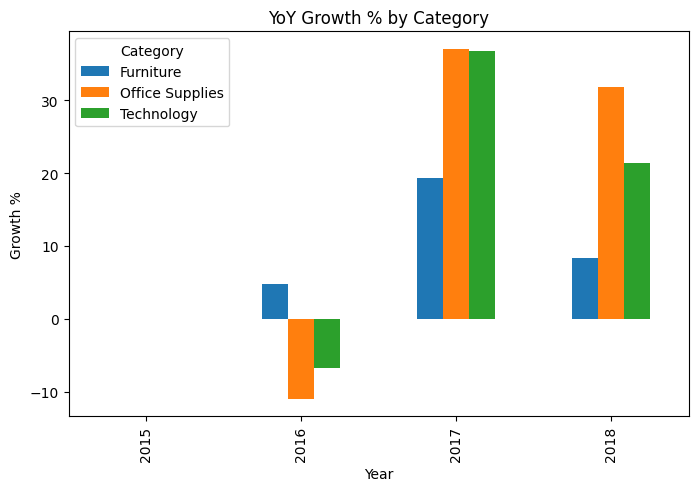

In [143]:
yoy_cat_growth.plot(kind='bar', figsize=(8,5))
plt.title('YoY Growth % by Category')
plt.ylabel('Growth %')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/yoy cat sales.png')
plt.show()

In [144]:
#year over year growth by segment
year_seg_sales = (
    data.groupby(['Year', 'Segment'])['Sales']
    .sum()
    .unstack()
)
year_seg_sales

Segment,Consumer,Corporate,Home Office
Year,,,
2015,262956.8006,127797.4957,89101.9118
2016,265356.2933,119675.5989,74404.1132
2017,291142.9652,204977.3178,104072.2670
2018,328604.4719,236043.6624,157403.8849


In [145]:
yoy_seg_growth = year_seg_sales.pct_change() * 100
yoy_seg_growth


Segment,Consumer,Corporate,Home Office
Year,,,
2015,NaN,NaN,NaN
2016,0.912505,-6.355286,-16.495492
2017,9.717754,71.277453,39.874346
2018,12.867049,15.155991,51.244793


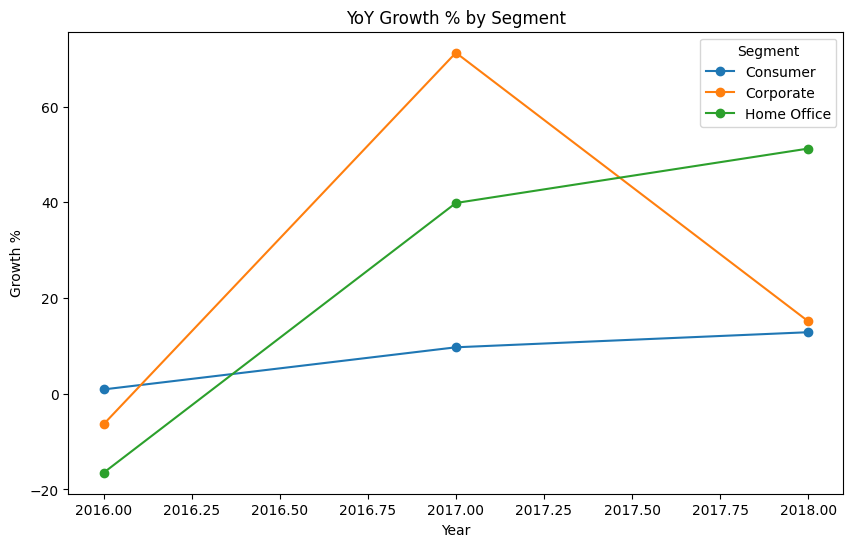

In [146]:
yoy_seg_growth.plot(kind='line', marker='o',figsize=(10,6))
plt.title('YoY Growth % by Segment')
plt.ylabel('Growth %')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/yoy seg sales.png')
plt.show()

In [147]:
#best year
best_year = yoy_growth.idxmax()
best_growth = yoy_growth.max()

best_year, best_growth

(np.int32(2017), np.float64(30.636811861850653))

In [148]:
#worst year
worst_year = yoy_growth.idxmin()
worst_growth = yoy_growth.min()

worst_year, worst_growth


(np.int32(2016), np.float64(-4.255483696012641))

In [149]:
#total sales by  categories
category_sales = data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

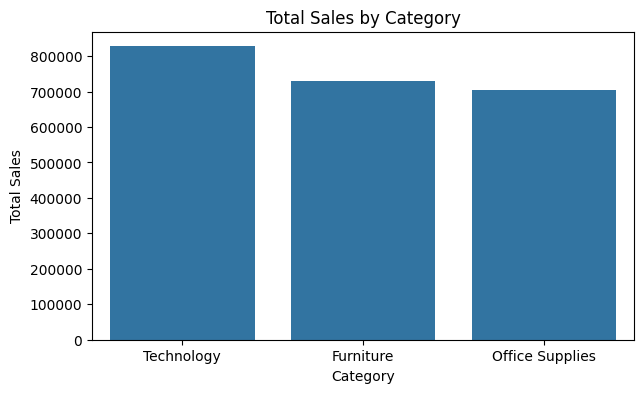

In [150]:
plt.figure(figsize=(7,4))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/category sales.png')
plt.show()

In [151]:
(category_sales / category_sales.sum()) * 100

Category
Technology         36.588212
Furniture          32.219621
Office Supplies    31.192167
Name: Sales, dtype: float64

In [152]:
#total sales by sub categories
subcat_sales = (
    data.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)
subcat_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

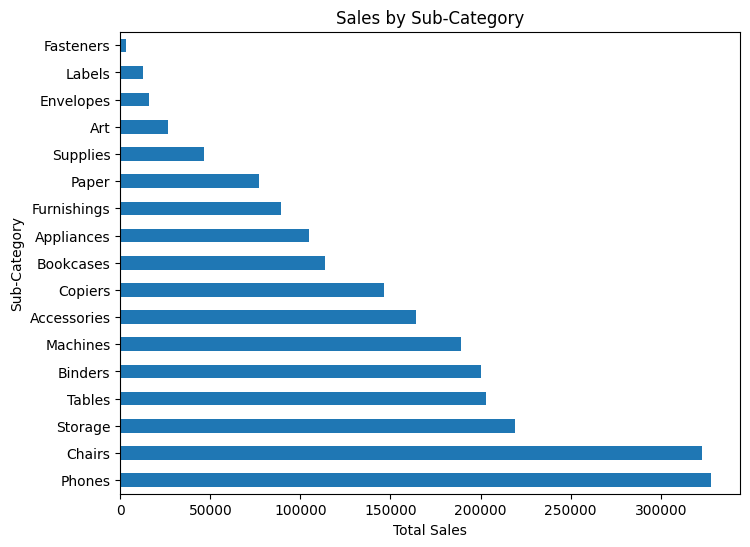

In [153]:
subcat_sales.plot(kind='barh', figsize=(8,6))
plt.title('Sales by Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/sub category sales.png')
plt.show()

In [154]:
#Group by Category + Sub-Category
cat_subcat_sales = (
    data.groupby(['Category', 'Sub-Category'])['Sales']
    .sum()
    .reset_index()
)
cat_subcat_sales.head()


,Category,Sub-Category,Sales
0,Furniture,Bookcases,113813.1987
1,Furniture,Chairs,322822.7310
2,Furniture,Furnishings,89212.0180
3,Furniture,Tables,202810.6280
4,Office Supplies,Appliances,104618.4030


In [155]:
#Sort within each Category
cat_subcat_sales = cat_subcat_sales.sort_values(
    ['Category', 'Sales'],
    ascending=[True, False]
)
cat_subcat_sales

,Category,Sub-Category,Sales
1,Furniture,Chairs,322822.7310
3,Furniture,Tables,202810.6280
0,Furniture,Bookcases,113813.1987
2,Furniture,Furnishings,89212.0180
11,Office Supplies,Storage,219343.3920
6,Office Supplies,Binders,200028.7850
4,Office Supplies,Appliances,104618.4030
10,Office Supplies,Paper,76828.3040
12,Office Supplies,Supplies,46420.3080
5,Office Supplies,Art,26705.4100


In [156]:
#Top 3 Sub-Categories per Category
top_subcats = cat_subcat_sales.groupby('Category').head(3)
top_subcats

,Category,Sub-Category,Sales
1,Furniture,Chairs,322822.7310
3,Furniture,Tables,202810.6280
0,Furniture,Bookcases,113813.1987
11,Office Supplies,Storage,219343.3920
6,Office Supplies,Binders,200028.7850
4,Office Supplies,Appliances,104618.4030
16,Technology,Phones,327782.4480
15,Technology,Machines,189238.6310
13,Technology,Accessories,164186.7000


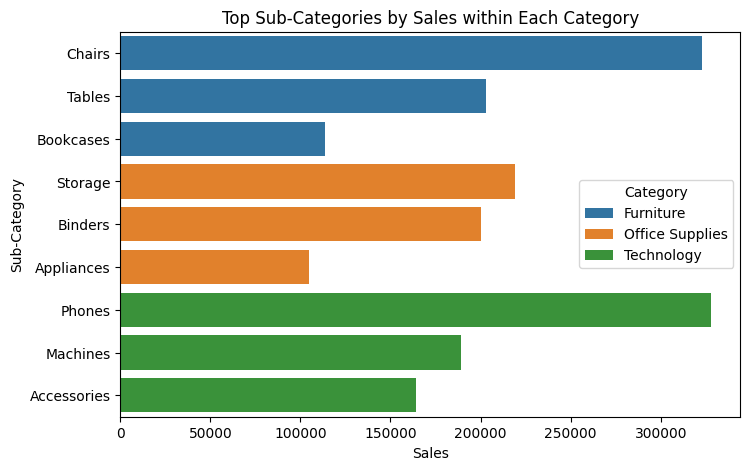

In [157]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=top_subcats,
    x='Sales',
    y='Sub-Category',
    hue='Category'
)
plt.title('Top Sub-Categories by Sales within Each Category')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/top sub cat sales.png')
plt.show()


In [158]:
top_products = (
    data.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

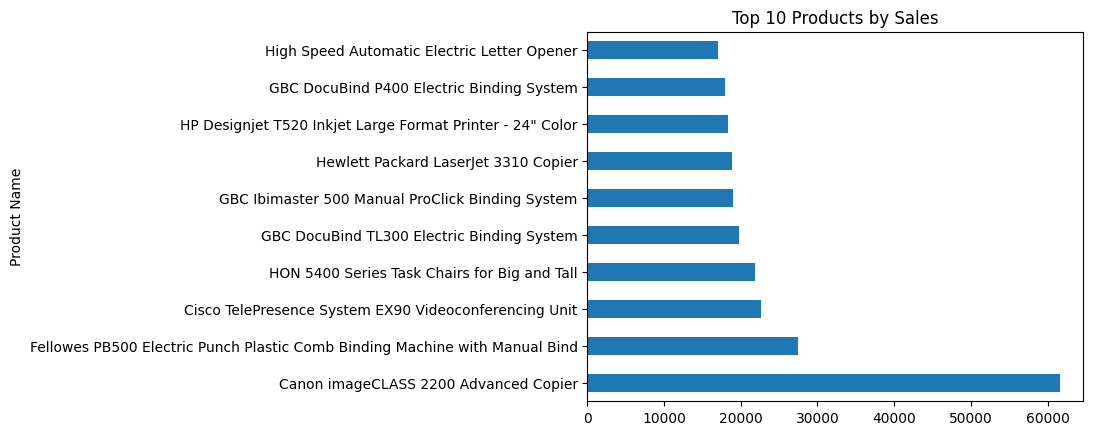

In [159]:
top_products.plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/top 10 sales.png')
plt.show()


In [160]:
segment_sales = data.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

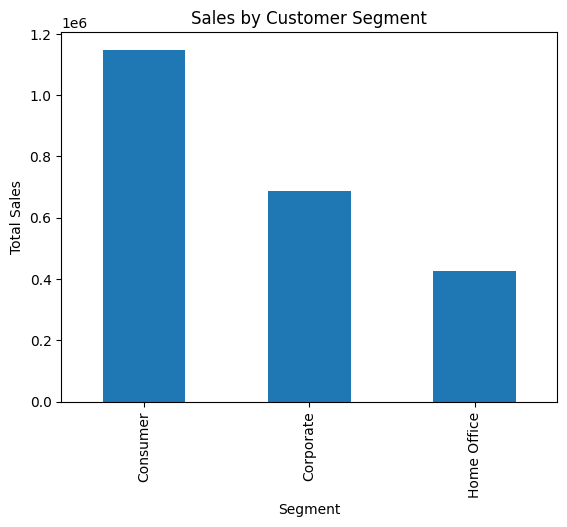

In [161]:
segment_sales.plot(kind='bar')
plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/segment sales.png')
plt.show()


In [162]:
#Sales by Segment & Category
seg_cat_sales = (
    data.groupby(['Segment', 'Category'])['Sales']
    .sum()
    .reset_index()
)
seg_cat_sales

,Segment,Category,Sales
0,Consumer,Furniture,387696.2580
1,Consumer,Office Supplies,359352.6080
2,Consumer,Technology,401011.6650
3,Corporate,Furniture,220321.7018
4,Corporate,Office Supplies,224130.5360
5,Corporate,Technology,244041.8370
6,Home Office,Furniture,120640.6159
7,Home Office,Office Supplies,121939.1900
8,Home Office,Technology,182402.3710


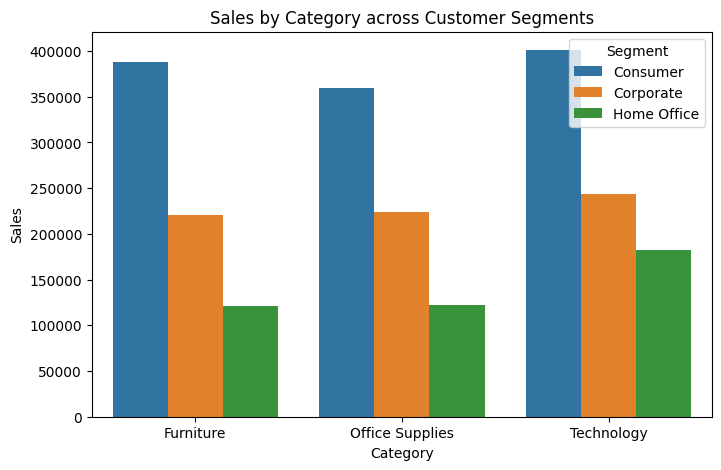

In [163]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=seg_cat_sales,
    x='Category',
    y='Sales',
    hue='Segment'
)
plt.title('Sales by Category across Customer Segments')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/cat seg sales.png')
plt.show()


In [164]:
#total sales per Category
category_total = (
    seg_cat_sales.groupby('Category')['Sales']
    .sum()
    .reset_index()
)
category_total


,Category,Sales
0,Furniture,728658.5757
1,Office Supplies,705422.3340
2,Technology,827455.8730


In [165]:
#Merge both
merged = seg_cat_sales.merge(category_total, on='Category', suffixes=('', '_Total'))
merged

,Segment,Category,Sales,Sales_Total
0,Consumer,Furniture,387696.2580,728658.5757
1,Consumer,Office Supplies,359352.6080,705422.3340
2,Consumer,Technology,401011.6650,827455.8730
3,Corporate,Furniture,220321.7018,728658.5757
4,Corporate,Office Supplies,224130.5360,705422.3340
5,Corporate,Technology,244041.8370,827455.8730
6,Home Office,Furniture,120640.6159,728658.5757
7,Home Office,Office Supplies,121939.1900,705422.3340
8,Home Office,Technology,182402.3710,827455.8730


In [166]:
#segment vs category - percentage
merged['Percentage'] = (merged['Sales'] / merged['Sales_Total']) * 100
merged

,Segment,Category,Sales,Sales_Total,Percentage
0,Consumer,Furniture,387696.2580,728658.5757,53.206848
1,Consumer,Office Supplies,359352.6080,705422.3340,50.941484
2,Consumer,Technology,401011.6650,827455.8730,48.463209
3,Corporate,Furniture,220321.7018,728658.5757,30.236617
4,Corporate,Office Supplies,224130.5360,705422.3340,31.772532
5,Corporate,Technology,244041.8370,827455.8730,29.493033
6,Home Office,Furniture,120640.6159,728658.5757,16.556536
7,Home Office,Office Supplies,121939.1900,705422.3340,17.285984
8,Home Office,Technology,182402.3710,827455.8730,22.043758


In [167]:
#regional sales
region_sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales


Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

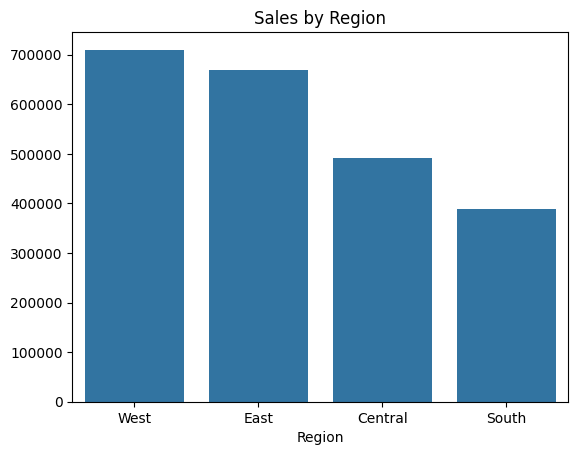

In [168]:
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Sales by Region')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/regional sales.png')
plt.show()

In [169]:
#average shipping days by ship mode
data.groupby('Ship Mode')['Shipping Days'].mean().sort_values()

Ship Mode
Same Day          0.044610
First Class       2.179214
Second Class      3.249211
Standard Class    5.008363
Name: Shipping Days, dtype: float64

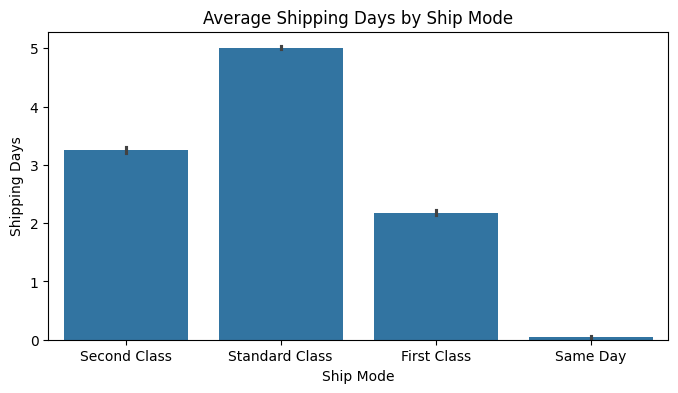

In [170]:
plt.figure(figsize=(8,4))
sns.barplot(x='Ship Mode', y='Shipping Days', data=data)
plt.title('Average Shipping Days by Ship Mode')
plt.savefig('C:/Users/chiru/OneDrive/Desktop/Figure/shipping days sales.png')
plt.show()

In [171]:
data['Ship Mode'].value_counts()

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

In [ ]:
Insights

##Sales by Month (Monthly Sales Trend)
Insights

Sales exhibit clear seasonality across all years, with certain months consistently recording higher sales.

Year-end months (September, November, and December) show peak sales, indicating strong end-of-year demand.

Early-year months (January and February) generally record lower sales compared to mid and end-year months.

##Sales by Year (Yearly Sales Trend)
Insights

Overall sales demonstrate strong long-term growth.

A slight slowdown is observed in 2016 compared to 2015, followed by a significant increase from 2017 onwards, indicating business recovery and expansion.

## Year-over-Year (YoY) Sales Growth %
Insight

Year-over-year growth shows a recovery phase in 2017 after weaker performance in 2016.

Growth in 2018 remains positive but is slower compared to 2017, indicating stabilization after rapid expansion.

##Year-over-Year Growth % by Category
Insight

Office Supplies shows the most aggressive growth in later years.

Technology, although a strong performer, grows at a comparatively slower pace after its rapid expansion.

Furniture records positive growth initially but shows slower growth in later years compared to other categories.

##Total Sales by Category
Insights

Technology is the highest revenue-generating category, reflecting strong customer demand.

Furniture ranks second, showing consistent performance but room for further growth.

Office Supplies contribute the least to total sales, possibly due to lower demand or lower-priced items.

##Sales by Sub-Category
Insights

Phones and Chairs are the highest-selling sub-categories, contributing significantly to overall revenue.

Sub-categories such as Fasteners, Labels, and Envelopes generate very low sales.

Sales are highly concentrated in a small number of sub-categories rather than evenly distributed.

##Top Sub-Categories by Sales within Each Category
Insights

In Furniture, Chairs and Tables dominate sales.

In Office Supplies, Storage and Binders contribute the highest sales.

In Technology, Phones lead sales, followed by Machines and Accessories.

## Top 10 Products by Sales
Insights

A small number of products contribute disproportionately to total sales.

High-value technology and office equipment products dominate the top 10 list.

Product sales are not evenly distributed across the catalog.

## Sales by Customer Segment
Insights

The Consumer segment contributes the largest share of total sales.

The Corporate segment is the second-largest contributor and shows strong growth potential.

The Home Office segment contributes the least sales, indicating a smaller customer base or lower order values.

## Yearly Sales by Segment
Insights

The Consumer segment shows steady and consistent growth across all years.

The Corporate segment experiences a strong increase after 2016.

The Home Office segment, while smaller, shows noticeable growth over time.

## Sales by Category across Customer Segments
Insights

The Consumer segment generates the highest sales across all categories.

Technology records the highest sales for every customer segment.

The Home Office segment contributes the least sales across categories.

## Sales by Region
Insights

The West region generates the highest sales.

The East region also performs strongly.

The South region contributes the lowest sales, indicating potential for improvement.

##Final Conclusion

Sales performance is primarily driven by Consumer customers, Technology products, and strong regional demand in the West and East regions.
Seasonal trends indicate strong year-end demand, while year-over-year analysis highlights recovery and sustained growth after 2016.
Although some categories and segments grow rapidly, sales remain concentrated in a limited set of products, sub-categories, and regions.

In [ ]:
Recommendations
## Focus on High-Performing Categories

Technology consistently generates the highest sales and should remain the company’s top priority.

Increase investment in inventory, marketing, and promotions for Technology products to maximize revenue.

##Leverage Year-End Seasonality

Sales peak during September, November, and December.

Plan inventory stocking, marketing campaigns, and discount strategies ahead of these high-demand months to avoid stockouts and maximize sales.

## Improve Low-Performing Categories

Office Supplies contribute the least to total sales.

Introduce bundling offers, cross-sell Office Supplies with Technology or Furniture products, and review pricing strategies to improve performance.

## Prioritize Key Customer Segments

The Consumer segment is the largest revenue contributor and should remain the main focus.

The Corporate segment shows strong growth potential; targeted B2B offers and long-term contracts can help increase revenue.

The Home Office segment, though smaller, shows growth and can be targeted with personalized offers.

## Strengthen Top-Selling Sub-Categories

Sub-categories like Phones, Chairs, Storage, and Tables drive a significant portion of total sales.

Focus marketing and inventory planning on these sub-categories to improve profitability.

## Optimize Product Portfolio

A small number of products contribute disproportionately to sales.

Ensure top-selling products are always available and featured prominently, while reviewing underperforming products for improvement or discontinuation.

##Expand Regional Growth

The West and East regions are the strongest markets and should be maintained with consistent strategies.

The South region shows lower sales and presents an opportunity for regional promotions, partnerships, or market expansion initiatives.

## Monitor Growth Trends Regularly

Use Year-over-Year growth analysis to identify early signs of slowdown or acceleration.

Regular monitoring can support better strategic planning and forecasting.

##Final Recommendation Summary 
By focusing on high-performing products and customer segments, preparing for seasonal demand, and improving underperforming categories and regions, 
the company can achieve sustainable growth and better resource utilization.